In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

In [9]:
import os
os.getcwd()

'C:\\Users\\LENOVO\\PycharmProjects\\product-recommendation-system'

In [8]:
%cd C:\\Users\\LENOVO\\PycharmProjects\\product-recommendation-system


C:\Users\LENOVO\PycharmProjects\product-recommendation-system


In [12]:
# ==============================
# LOAD DATA
# ==============================

products = pd.read_csv("data/raw/products_10k.csv")
interactions = pd.read_csv("data/raw/interactions_10k.csv")

print("Products Shape:", products.shape)
print("Interactions Shape:", interactions.shape)

products.head()

Products Shape: (200, 8)
Interactions Shape: (10000, 5)


,product_id,product_name,category,sub_category,brand,price,description,rating
0,P0001,Adidas Accessories Model 1,Sports,Accessories,Adidas,1049,"Adidas Accessories with premium quality, lates...",4.6
1,P0002,Asus Tablets Model 2,Electronics,Tablets,Asus,454,"Asus Tablets with premium quality, latest tech...",3.8
2,P0003,HP Laptops Model 3,Electronics,Laptops,HP,1794,"HP Laptops with premium quality, latest techno...",5.0
3,P0004,Dell Cookware Model 4,Home & Kitchen,Cookware,Dell,1177,"Dell Cookware with premium quality, latest tec...",4.7
4,P0005,Dell Fitness Model 5,Sports,Fitness,Dell,277,"Dell Fitness with premium quality, latest tech...",4.9


In [13]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    200 non-null    str    
 1   product_name  200 non-null    str    
 2   category      200 non-null    str    
 3   sub_category  200 non-null    str    
 4   brand         200 non-null    str    
 5   price         200 non-null    int64  
 6   description   200 non-null    str    
 7   rating        200 non-null    float64
dtypes: float64(1), int64(1), str(6)
memory usage: 12.6 KB


In [14]:
interactions.head()

,user_id,product_id,interaction_type,timestamp,rating
0,U00017,P0165,purchase,2025-03-13 05:29:19.825546,3.5
1,U00011,P0054,cart,2025-11-27 05:29:19.825568,NaN
2,U00681,P0039,purchase,2025-08-28 05:29:19.825576,4.5
3,U00805,P0167,cart,2026-01-14 05:29:19.825582,NaN
4,U00995,P0017,purchase,2025-06-28 05:29:19.825588,4.0


In [15]:
interactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           10000 non-null  str    
 1   product_id        10000 non-null  str    
 2   interaction_type  10000 non-null  str    
 3   timestamp         10000 non-null  str    
 4   rating            3422 non-null   float64
dtypes: float64(1), str(4)
memory usage: 390.8 KB


In [17]:
# ==============================
# DATA CLEANING
# ==============================

# Convert timestamp
interactions['timestamp'] = pd.to_datetime(interactions['timestamp'])

In [18]:
# Check missing values
print(products.isnull().sum())
print(interactions.isnull().sum())

product_id      0
product_name    0
category        0
sub_category    0
brand           0
price           0
description     0
rating          0
dtype: int64
user_id                0
product_id             0
interaction_type       0
timestamp              0
rating              6578
dtype: int64


In [22]:
# Drop duplicates
print(f"Duplicated values in Products df :{products.duplicated().sum()}")
print(f"Duplicated values in Products df :{interactions.duplicated().sum()}")


Duplicated values in Products df :0
Duplicated values in Products df :0


In [23]:
# Drop duplicates
#products.drop_duplicates(inplace=True)
#interactions.drop_duplicates(inplace=True)

## EDA (Exploratory Data Analysis)

#### Category Distribution


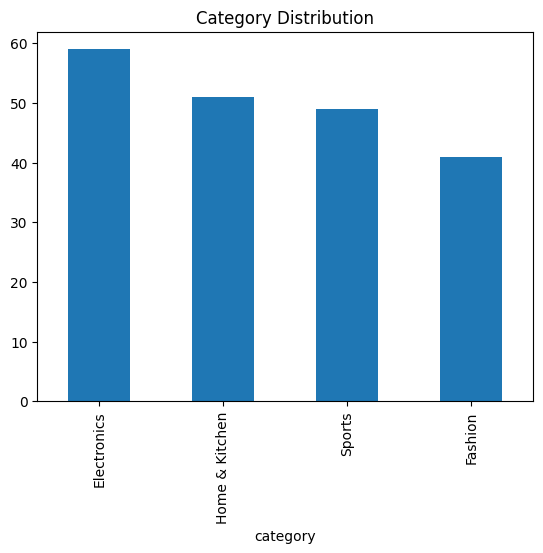

In [24]:
plt.figure()
products['category'].value_counts().plot(kind='bar')
plt.title("Category Distribution")
plt.show()

#### Price Distribution

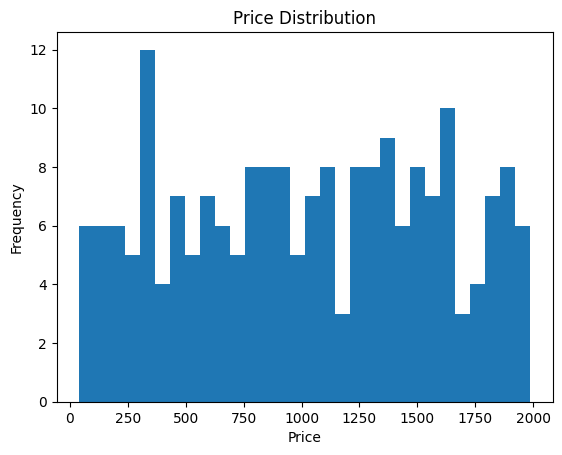

In [25]:
plt.figure()
products['price'].plot(kind='hist', bins=30)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.show()

#### Rating Distribution

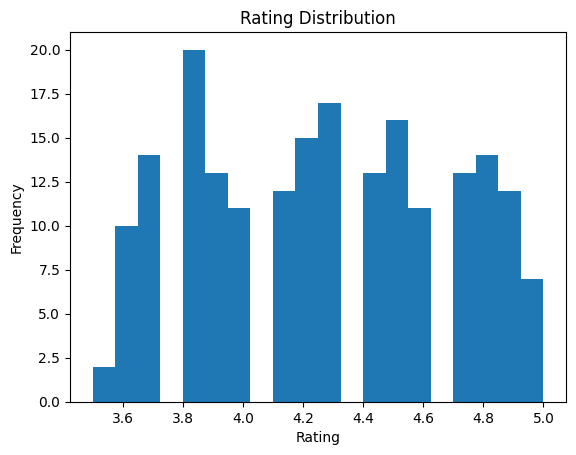

In [26]:
plt.figure()
products['rating'].plot(kind='hist', bins=20)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.show()

#### 🔹 Interaction Type Distribution


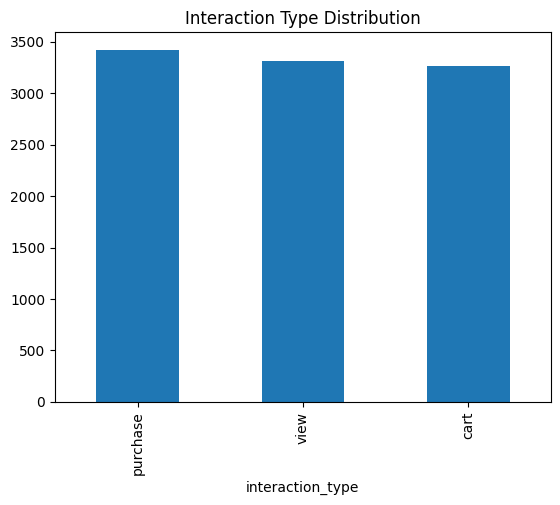

In [27]:
plt.figure()
interactions['interaction_type'].value_counts().plot(kind='bar')
plt.title("Interaction Type Distribution")
plt.show()

#### 🔹 Top Purchased Products

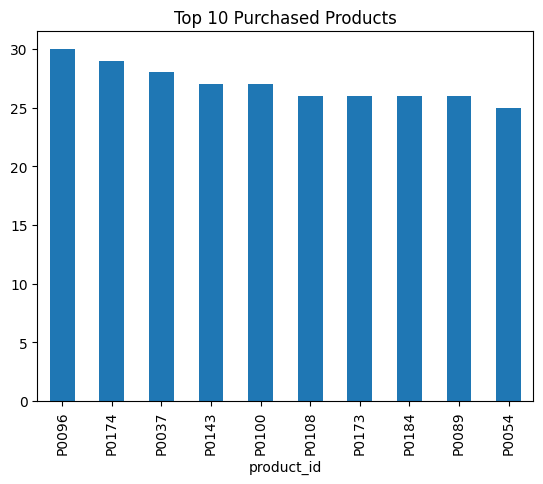

In [28]:
purchases = interactions[interactions['interaction_type'] == "purchase"]

plt.figure()
purchases['product_id'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Purchased Products")
plt.show()

## Feature Engineering

#### Combine product features into one text column.

In [29]:
# ==============================
# FEATURE ENGINEERING
# ==============================

products['combined_features'] = (
    products['category'] + " " +
    products['sub_category'] + " " +
    products['brand'] + " " +
    products['description']
)

products[['product_name', 'combined_features']].head()

,product_name,combined_features
0,Adidas Accessories Model 1,Sports Accessories Adidas Adidas Accessories w...
1,Asus Tablets Model 2,Electronics Tablets Asus Asus Tablets with pre...
2,HP Laptops Model 3,Electronics Laptops HP HP Laptops with premium...
3,Dell Cookware Model 4,Home & Kitchen Cookware Dell Dell Cookware wit...
4,Dell Fitness Model 5,Sports Fitness Dell Dell Fitness with premium ...


## TF-IDF Vectorization

In [30]:
# ==============================
# TF-IDF TRANSFORMATION
# ==============================

tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(products['combined_features'])

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (200, 38)


## Cosine Similarity Model

In [31]:
# ==============================
# COSINE SIMILARITY
# ==============================

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print("Cosine Similarity Shape:", cosine_sim.shape)

Cosine Similarity Shape: (200, 200)


## Recommendation Function (Product-Based)

In [32]:
# ==============================
# PRODUCT RECOMMENDATION FUNCTION
# ==============================

indices = pd.Series(products.index, index=products['product_id']).drop_duplicates()

def recommend_products(product_id, top_n=5):

    idx = indices[product_id]

    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    sim_scores = sim_scores[1:top_n+1]

    product_indices = [i[0] for i in sim_scores]

    return products[['product_id', 'product_name', 'category', 'brand']].iloc[product_indices]

#### Test Product Recommendation

In [33]:
recommend_products("P0001", top_n=5)

,product_id,product_name,category,brand
44,P0045,Adidas Accessories Model 45,Sports,Adidas
107,P0108,Adidas Accessories Model 108,Sports,Adidas
9,P0010,Dell Accessories Model 10,Sports,Dell
45,P0046,Dell Accessories Model 46,Sports,Dell
172,P0173,Dell Accessories Model 173,Sports,Dell


####

In [34]:
# ==============================
# USER-BASED RECOMMENDATION
# ==============================

def recommend_for_user(user_id, top_n=5):

    user_data = interactions[
        (interactions['user_id'] == user_id) &
        (interactions['interaction_type'] == "purchase")
    ]

    if user_data.empty:
        return "No purchase history found."

    last_product = user_data.sort_values("timestamp").iloc[-1]['product_id']

    return recommend_products(last_product, top_n)

In [35]:
#Test User Recommendation
recommend_for_user("U00001", top_n=5)

,product_id,product_name,category,brand
44,P0045,Adidas Accessories Model 45,Sports,Adidas
107,P0108,Adidas Accessories Model 108,Sports,Adidas
9,P0010,Dell Accessories Model 10,Sports,Dell
45,P0046,Dell Accessories Model 46,Sports,Dell
172,P0173,Dell Accessories Model 173,Sports,Dell


## Basic Evaluation (Precision@K Approximation)

#### For portfolio-level evaluation:

In [36]:
# ==============================
# BASIC EVALUATION
# ==============================

def precision_at_k(user_id, k=5):

    user_purchases = interactions[
        (interactions['user_id'] == user_id) &
        (interactions['interaction_type'] == "purchase")
    ]

    if len(user_purchases) < 2:
        return None

    actual_products = user_purchases['product_id'].values

    recommended = recommend_products(actual_products[0], k)['product_id'].values

    relevant = len(set(actual_products[1:]) & set(recommended))

    return relevant / k

In [41]:
print("Sample Precision@5:", precision_at_k("U00009", 5))

Sample Precision@5: 0.0


In [ ]:
#Save Model (Production Step)

import pickle

#pickle.dump(tfidf, open("../models/tfidf.pkl", "wb"))
#pickle.dump(cosine_sim, open("../models/cosine_sim.pkl", "wb"))
